In [3]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from functions import *
from scipy.stats import ks_2samp, mannwhitneyu, anderson_ksamp, pearsonr
import warnings
warnings.filterwarnings('ignore')

In [8]:
data = pd.read_csv('results/data.csv', index_col='Cluster')
df = pd.read_csv('results/results.csv', index_col ='Cluster')

# Corte de binárias por dm1/M1 <0.5

In [32]:
mask = (dados['er_mass']/dados['mass']) < 0.5
aux_1 = dados[mask].copy()

df1 = df.copy()
for cluster in df1.index:
    df1.loc[cluster, 'bin_frac'] = bin_frac(aux_1.loc[cluster])
    df1.loc[cluster, 'bin_frac_corr'] = corr_fb_by_similarity(df1, 'bin_frac', cluster)

In [33]:
print(f'Quantidade de sistemas excluidos: {len(data) - len(aux_1)}')

Quantidade de sistemas excluidos: 2109


In [34]:
df1[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,772.00,772.00
mean,0.58,0.51
std,0.12,0.09
min,0.17,0.29
25%,0.50,0.46
50%,0.58,0.50
75%,0.65,0.55
max,0.90,0.83


In [35]:
aux_1[aux_1['q']>0][['q','comp_mass']].describe().round(2)

,q,comp_mass
count,87355.00,87355.00
mean,0.61,0.84
std,0.26,0.78
min,0.01,0.10
25%,0.43,0.41
50%,0.66,0.74
75%,0.84,1.07
max,0.99,30.43


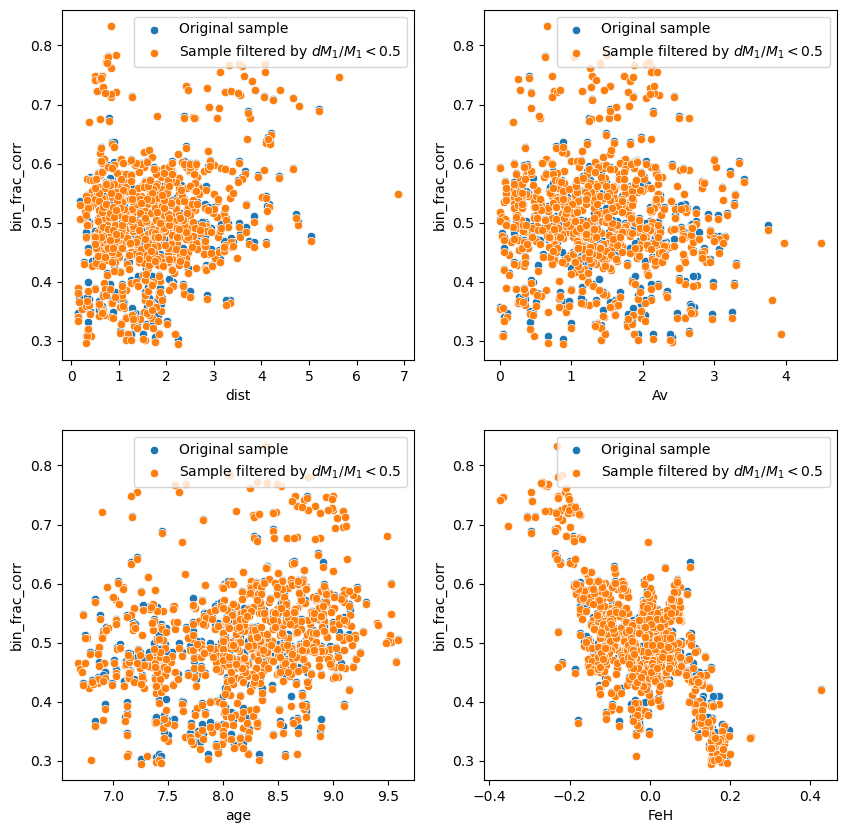

In [36]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='Original sample')
    sns.scatterplot(data=df1, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'Sample filtered by $dM_1/M_1 < 0.5$')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

## Refazer análises com a nova amostra filtrada por $\delta M_1/M_1<0.5$

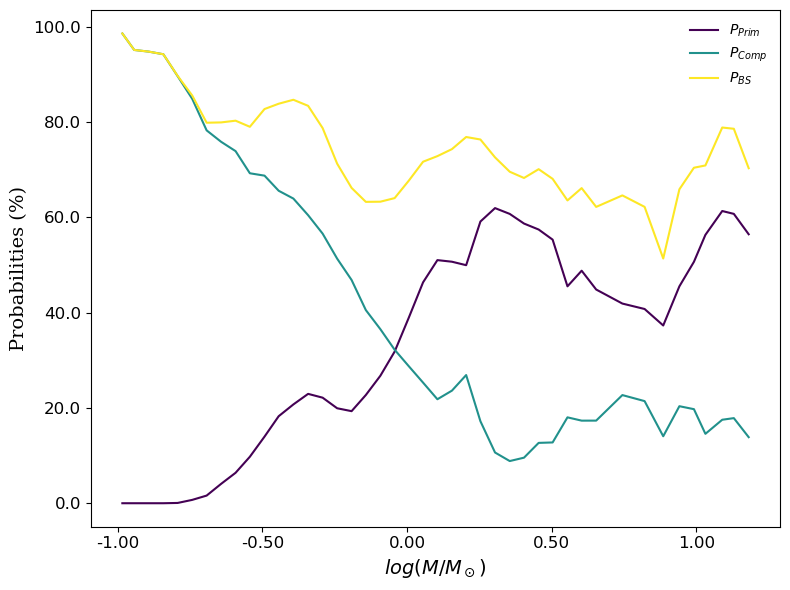

In [37]:
m1 = aux_1['mass'].values
m2 = aux_1['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa2.png', dpi=300)
plt.show()



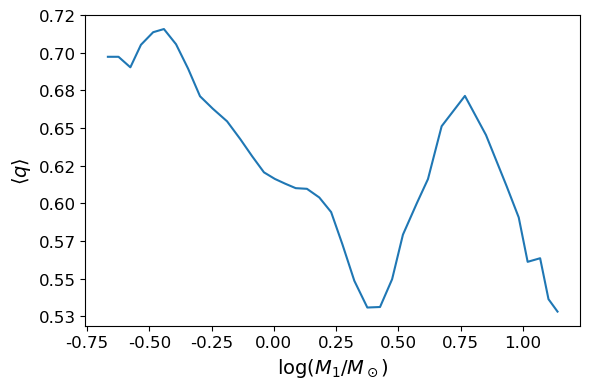

In [38]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 



# Corte de binárias por dm2/M2 <0.5

In [39]:
mask = ((dados['er_comp_mass']/dados['comp_mass']) < 0.5) | (dados['comp_mass'] == 0)
aux_2 = dados[mask].copy()

df2 = df.copy()
for cluster in df2.index:
    df2.loc[cluster, 'bin_frac'] = bin_frac(aux_2.loc[cluster])
    df2.loc[cluster, 'bin_frac_corr'] = corr_fb_by_similarity(df2, 'bin_frac', cluster)

In [40]:
print(f'Quantidade de sistemas excluidos: {(len(data) - len(aux_2))}')

Quantidade de sistemas excluidos: 25881


In [41]:
aux_2[aux_2['q']>0][['q', 'comp_mass']].describe().round(2)

,q,comp_mass
count,63583.00,63583.00
mean,0.74,1.03
std,0.14,0.80
min,0.34,0.10
25%,0.62,0.67
50%,0.76,0.90
75%,0.87,1.20
max,0.99,30.43


In [47]:
df2[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,772.00,772.00
mean,0.50,0.48
std,0.13,0.11
min,0.15,0.26
25%,0.41,0.41
50%,0.50,0.47
75%,0.59,0.53
max,0.87,0.81


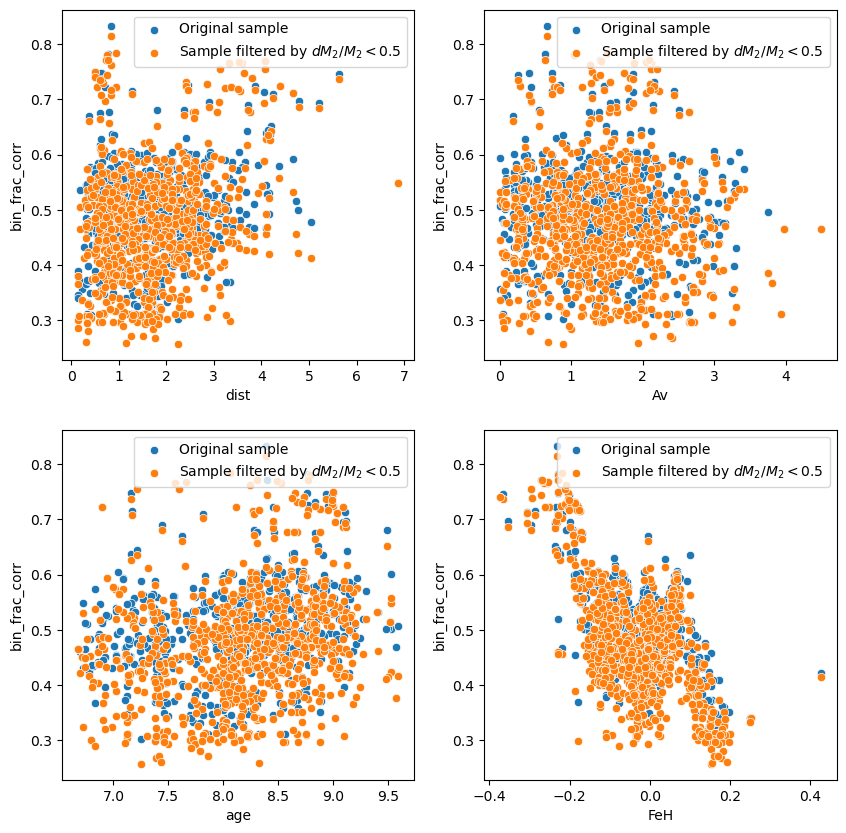

In [48]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='Original sample')
    sns.scatterplot(data=df2, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'Sample filtered by $dM_2/M_2 < 0.5$')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

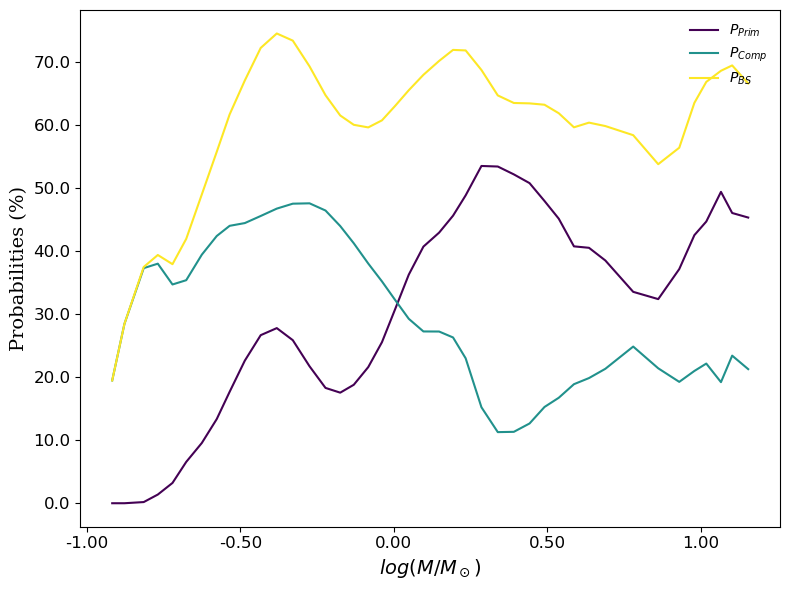

In [49]:
m1 = aux_2['mass'].values
m2 = aux_2['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa2.png', dpi=300)
plt.show()


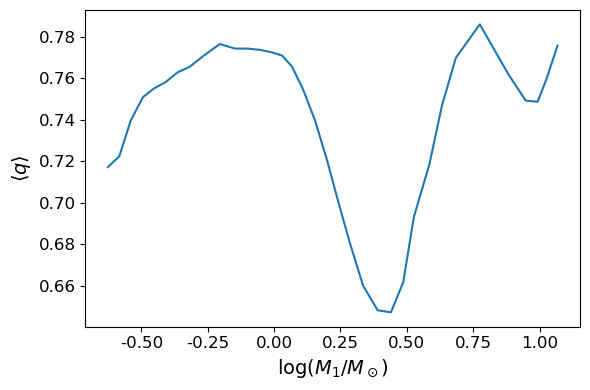

In [50]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 


# Corte por $\delta q/q<0.5$

In [57]:
mask = ((data['er_q']/data['q']) <0.5) | (data['q'] == 0)
aux_3 = dados[mask].copy()
df3 = df.copy()
for cluster in df3.index:
    df3.loc[cluster, 'bin_frac'] = bin_frac(aux_3.loc[cluster])
    df3.loc[cluster, 'bin_frac_corr'] = corr_fb_by_similarity(df3, 'bin_frac', cluster)

In [60]:
print(f'Quantidade de sistemas excluidos: {(len(dados) - len(aux_3))}')

Quantidade de sistemas excluidos: 25902


In [61]:
aux_3[aux_3['q']>0][['q', 'comp_mass']].describe().round(2)

,q,comp_mass
count,63562.00,63562.00
mean,0.74,1.03
std,0.14,0.80
min,0.34,0.10
25%,0.62,0.67
50%,0.76,0.90
75%,0.87,1.20
max,0.99,30.43


In [63]:
df3[['bin_frac', 'bin_frac_corr']].describe().round(2)

,bin_frac,bin_frac_corr
count,772.00,772.00
mean,0.50,0.48
std,0.13,0.11
min,0.15,0.26
25%,0.41,0.41
50%,0.50,0.47
75%,0.59,0.53
max,0.87,0.81


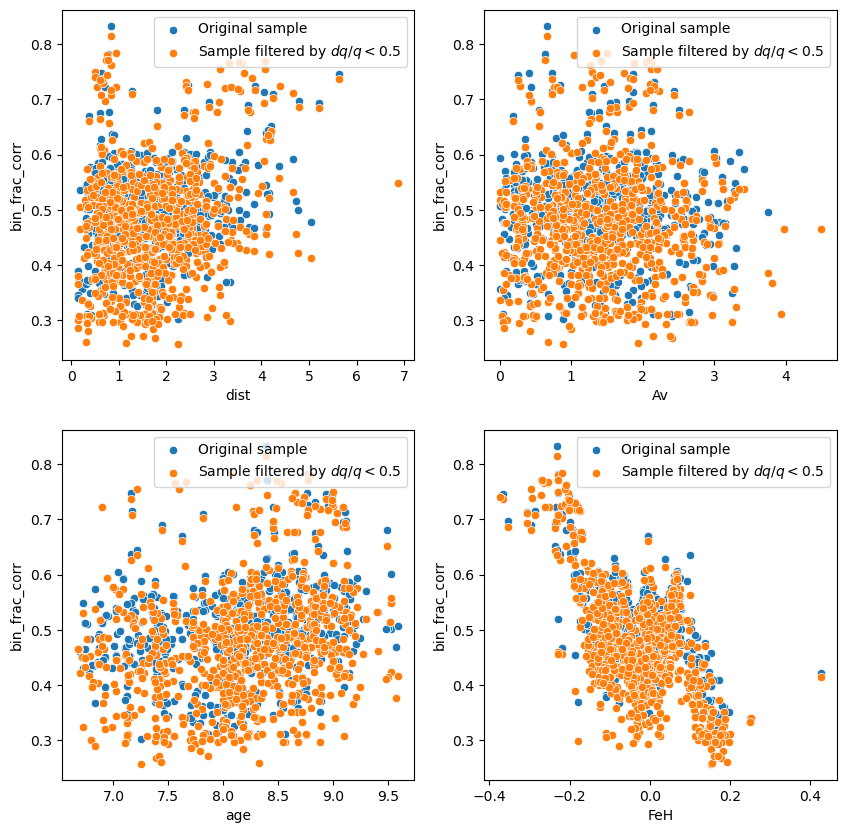

In [65]:
fig, axs = plt.subplots(2,2, figsize = (10,10))
var_ = ['dist', 'Av', 'age', 'FeH']
i, j = 0, 0
for var in var_:
    sns.scatterplot(data=df, x=var, y='bin_frac_corr', ax = axs[i,j], label='Original sample')
    sns.scatterplot(data=df3, x=var, y='bin_frac_corr', ax = axs[i,j], label= r'Sample filtered by $dq/q < 0.5$')
    j+=1
    if j>1:
        j=0
        i+=1 
plt.legend()
plt.show()

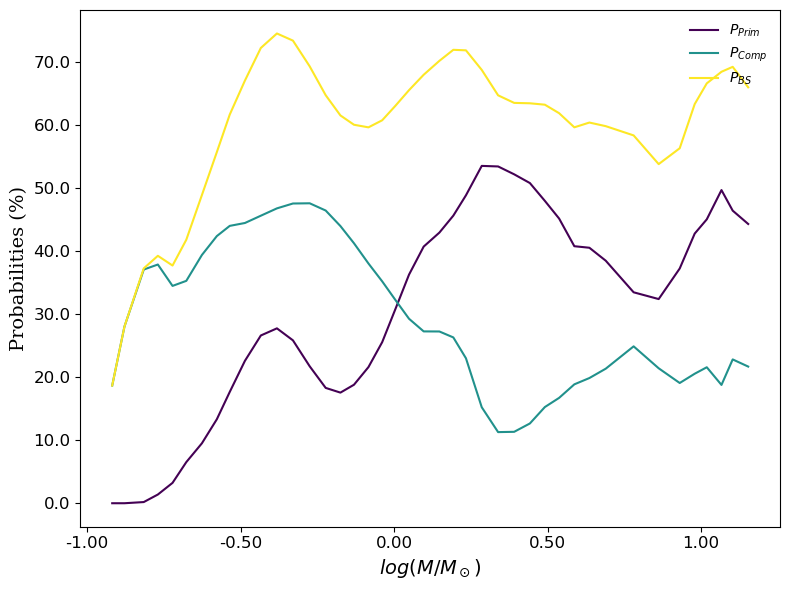

In [66]:
m1 = aux_3['mass'].values
m2 = aux_3['comp_mass'].values
q=m2/m1

log_m1 = np.log10(m1)
log_m2 = np.log10(m2)

min_mass = min(log_m1.min(), log_m2[log_m2>0].min())
max_mass = log_m1.max()

mass_bins, P_prim, P_comp, P_BS = loop_probabilities(log_m1, log_m2, min_mass, max_mass, dm=0.05)


nominal_values = [P_prim, P_comp, P_BS]

labels = [r'$P_{Prim}$', r'$P_{Comp}$', r'$P_{BS}$']
cmap = plt.cm.viridis
cores = cmap(np.linspace(0, 1, 3))


fig, axs = plt.subplots(figsize=(8,6))

for i in range(0, len(nominal_values)):
    axs.plot(mass_bins,  nominal_values[i]*100,label = labels[i], color = cores[i])    
    
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
axs.set_ylabel(r'Probabilities (%)', fontdict=font)
axs.set_xlabel(r'$log(M/M_\odot)$', fontdict=font)
plt.legend(loc='upper right',frameon=False)
plt.tight_layout()
#plt.savefig('Figures/dist_fb_por_massa2.png', dpi=300)
plt.show()


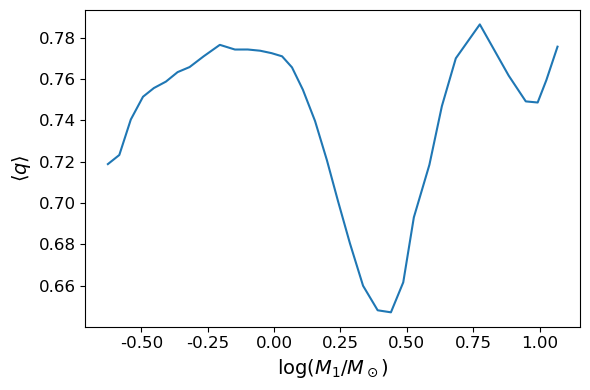

In [67]:
q = m2/m1
log_m1_bin = np.log10(m1[q>0])

min_mass = log_m1_bin.min()
max_mass = log_m1_bin.max()

mass_bins, qs = loop_mass_ratio(log_m1_bin, q[q>0], min_mass, max_mass, dm=0.05)

fig, axs = plt.subplots(figsize=(6,4))

axs.plot(mass_bins, qs)

axs.set_ylabel(r'$\langle q \rangle$', fontdict=font)
axs.set_xlabel(r'$\log(M_1/M_\odot)$', fontdict=font)
axs.tick_params(labelleft=True, labelbottom=True, labelsize=labelsize)
axs.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
axs.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.tight_layout()
#plt.savefig('Figures/dist_q_por_massa.png', dpi=300)
plt.show() 


# Comparação dos cortes

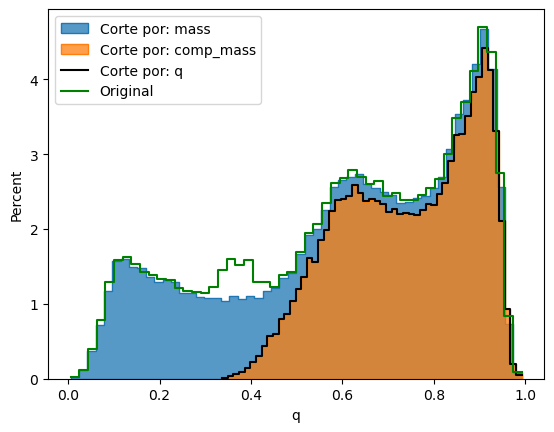

In [68]:
sns.histplot(x = aux_1[aux_1['q']>0]['q'], stat='percent' , element = 'step', label ='Corte por: mass')
sns.histplot(x = aux_2[aux_2['q']>0]['q'], stat='percent' , element = 'step', label ='Corte por: comp_mass')
sns.histplot(x = aux_3[aux_3['q']>0]['q'], stat='percent' , element = 'step', label ='Corte por: q', fill=False, color ='k')
sns.histplot(x = dados[dados['q']>0]['q'], stat='percent' , element = 'step', label ='Original', 
             fill=False, color='green')
plt.legend()
plt.show()

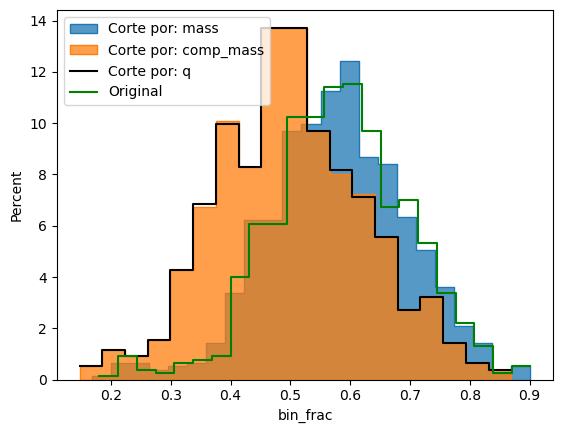

In [69]:
sns.histplot(df1['bin_frac'], stat='percent', element='step', label ='Corte por: mass')
sns.histplot(df2['bin_frac'], stat='percent', element='step', label ='Corte por: comp_mass')
sns.histplot(df3['bin_frac'], stat='percent', element='step', label ='Corte por: q', fill = False, color = 'k')

sns.histplot(x = df['bin_frac'], stat='percent' , element = 'step', label ='Original', 
             fill=False, color='green')
plt.legend()
plt.show()

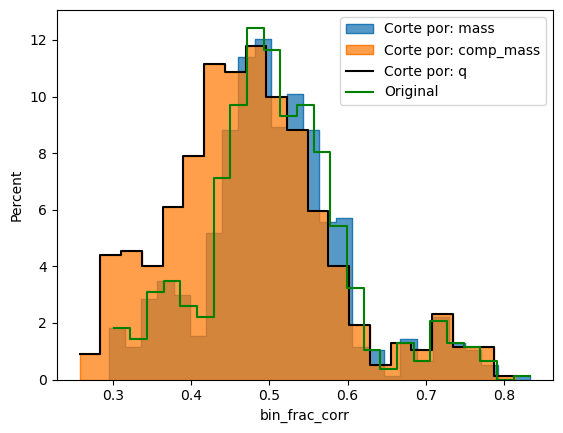

In [70]:
#Distribuição dos valores corrigidos de fb

sns.histplot(df1['bin_frac_corr'], stat='percent', element='step', label ='Corte por: mass')
sns.histplot(df2['bin_frac_corr'], stat='percent', element='step', label ='Corte por: comp_mass')
sns.histplot(df3['bin_frac_corr'], stat='percent', element='step', label ='Corte por: q', fill = False, color = 'k')
sns.histplot(x = df['bin_frac_corr'], stat='percent' , element = 'step', label ='Original', 
             fill=False, color='green')
plt.legend()